# Customer Segmentation — RFM Analysis & Cohort Retention

**Dataset:** [UCI Online Retail Dataset — Kaggle](https://www.kaggle.com/datasets/lakshmi25npathi/online-retail-dataset)  
**Records:** ~541,909 transactions | UK-based online gift retailer | Dec 2010 – Dec 2011  
**Business Question:** Which customers are most valuable, which are at risk of churning, and how does customer retention change over time?

**Techniques Used:** RFM Scoring, Customer Segmentation, Cohort Retention Analysis  
**Tools:** Python, Pandas, Matplotlib, Seaborn

---

## 1. Setup & Libraries

In [23]:
# Uncomment to install on first run
# !pip install kagglehub pandas matplotlib seaborn

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import glob

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (11, 5)

## 2. Load Data — Direct from Kaggle

**Prerequisites (one-time setup):**
1. Go to [https://www.kaggle.com/settings](https://www.kaggle.com/settings) → API → **Create New Token**
2. Place the downloaded `kaggle.json` at `~/.kaggle/kaggle.json`
3. Linux/Mac: run `chmod 600 ~/.kaggle/kaggle.json`

Or set credentials via environment variables below:

In [25]:
# Option: set credentials via env variables
# (skip if kaggle.json is already in ~/.kaggle/)
# os.environ['KAGGLE_USERNAME'] = 'your_username'
# os.environ['KAGGLE_KEY']      = 'your_api_key'

In [26]:
import kagglehub

# Download dataset — cached locally after first run
# Source: https://www.kaggle.com/datasets/lakshmi25npathi/online-retail-dataset
dataset_path = kagglehub.dataset_download('lakshmi25npathi/online-retail-dataset')
print(f'Downloaded to: {dataset_path}')

# List files
all_files = glob.glob(f'{dataset_path}/**/*', recursive=True)
for f in all_files:
    print(' ', f)

Downloaded to: C:\Users\ASUS\.cache\kagglehub\datasets\lakshmi25npathi\online-retail-dataset\versions\1
  C:\Users\ASUS\.cache\kagglehub\datasets\lakshmi25npathi\online-retail-dataset\versions\1\online_retail_II.xlsx


In [27]:
# The dataset is an Excel file (.xlsx)
xlsx_files = glob.glob(f'{dataset_path}/**/*.xlsx', recursive=True)
csv_files  = glob.glob(f'{dataset_path}/**/*.csv',  recursive=True)

if xlsx_files:
    df = pd.read_excel(xlsx_files[0], engine='openpyxl')
elif csv_files:
    df = pd.read_csv(csv_files[0], encoding='ISO-8859-1', low_memory=False)
else:
    raise FileNotFoundError('No .xlsx or .csv found in downloaded dataset path.')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(4)

Shape: (525461, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom


## 3. Data Cleaning

In [28]:
# Check nulls
print('Null counts:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Null counts:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

Duplicate rows: 6865


In [29]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Drop rows with no CustomerID — can't do customer-level analysis without it
df.dropna(subset=['customer_id'], inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)

# Parse invoice date
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

# Remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df['invoice'].astype(str).str.startswith('C')]

# Remove rows with negative or zero quantity/unit price
df = df[(df['quantity'] > 0) & (df['price'] > 0)]

# Compute revenue per line
df['revenue'] = df['quantity'] * df['price']

# Cast CustomerID to int
df['customer_id'] = df['customer_id'].astype(int)

print(f'Clean dataset shape: {df.shape}')
df.dtypes

Clean dataset shape: (400916, 9)


invoice                object
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[ns]
price                 float64
customer_id             int64
country                object
revenue               float64
dtype: object

## 4. Exploratory Data Analysis

### 4.1 Monthly Revenue Trend

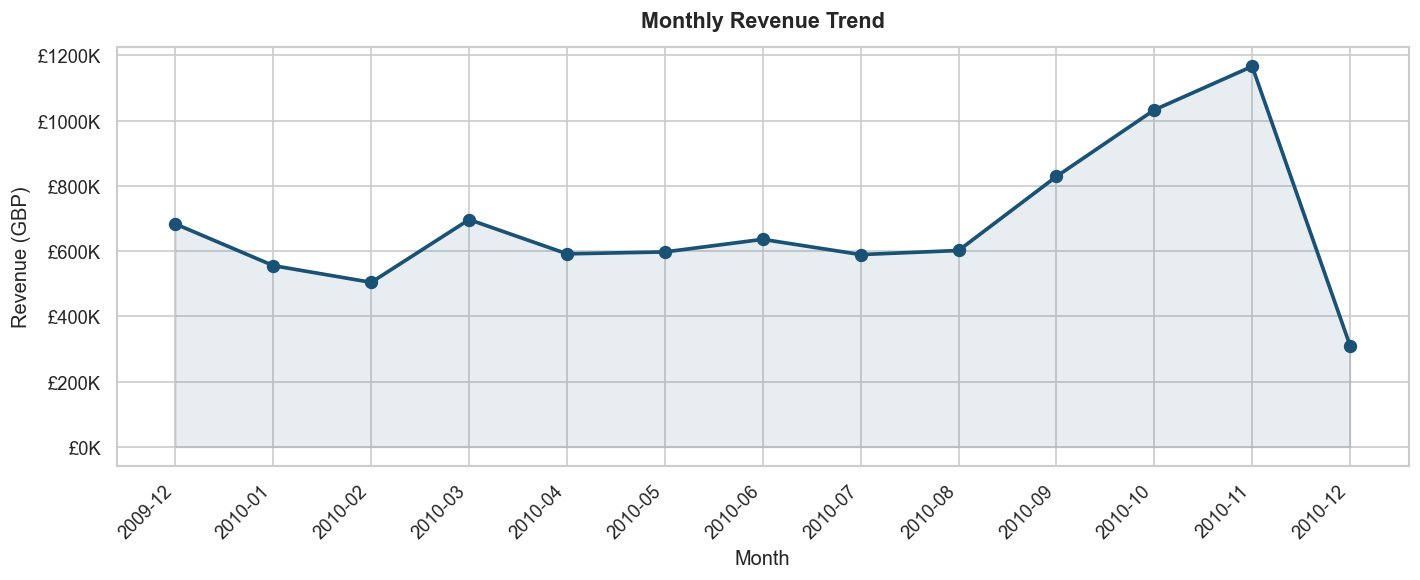

In [30]:
df['month'] = df['invoicedate'].dt.to_period('M')

monthly_rev = (
    df.groupby('month')['revenue']
    .sum()
    .reset_index()
    .sort_values('month')
)
monthly_rev['month_str'] = monthly_rev['month'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_rev['month_str'], monthly_rev['revenue'],
        marker='o', linewidth=2.2, color='#1A5276', markersize=7)
ax.fill_between(monthly_rev['month_str'], monthly_rev['revenue'],
                alpha=0.1, color='#1A5276')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
ax.set_title('Monthly Revenue Trend', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (GBP)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('monthly_revenue.png', bbox_inches='tight')
plt.show()

### 4.2 Top 10 Countries by Revenue

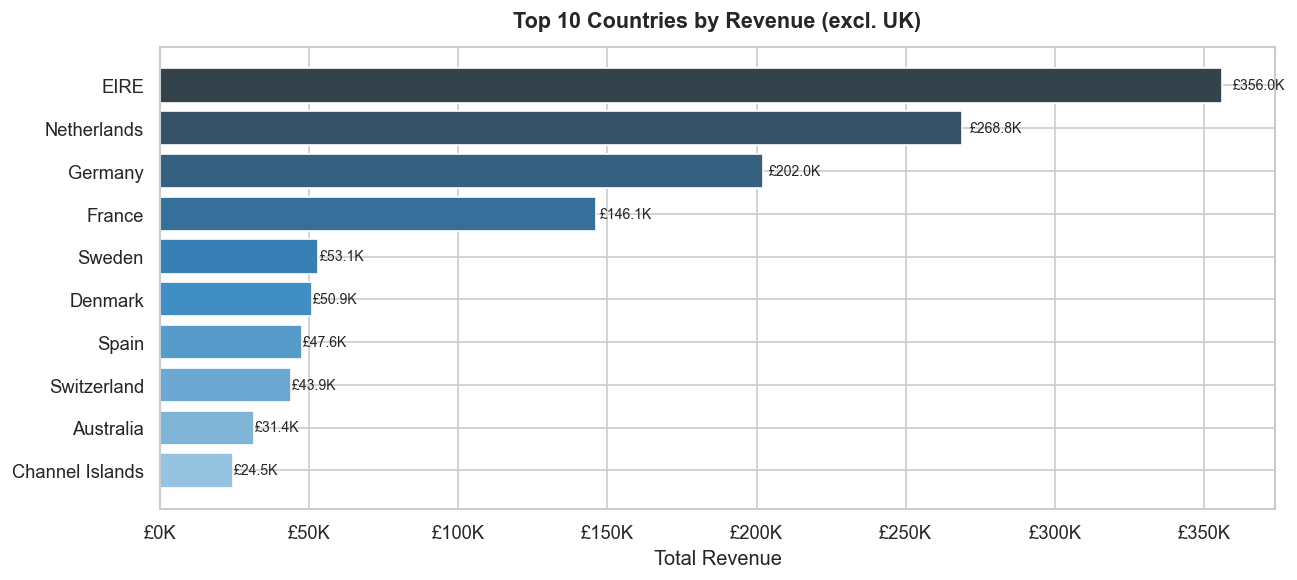

In [31]:
country_rev = (
    df[df['country'] != 'United Kingdom']  # UK dominates; exclude to show others
    .groupby('country')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
    country_rev['country'][::-1],
    country_rev['revenue'][::-1],
    color=sns.color_palette('Blues_d', 10)
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
ax.set_title('Top 10 Countries by Revenue (excl. UK)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Total Revenue')

for bar in bars:
    w = bar.get_width()
    ax.text(w * 1.01, bar.get_y() + bar.get_height() / 2,
            f'£{w/1e3:.1f}K', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('top_countries.png', bbox_inches='tight')
plt.show()

## 5. RFM Analysis

**RFM** measures customer value across three dimensions:
- **Recency (R):** How recently did a customer purchase? (lower = better)
- **Frequency (F):** How many times did they buy? (higher = better)
- **Monetary (M):** How much did they spend in total? (higher = better)

In [32]:
# Snapshot date = 1 day after last transaction (used to calculate recency)
snapshot_date = df['invoicedate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {snapshot_date.date()}')

rfm = (
    df.groupby('customer_id')
    .agg(
        recency   = ('invoicedate', lambda x: (snapshot_date - x.max()).days),
        frequency = ('invoice',     'nunique'),
        monetary  = ('revenue',     'sum')
    )
    .reset_index()
)

print(f'\nRFM table shape: {rfm.shape}')
rfm.describe().round(2)

Snapshot date: 2010-12-10

RFM table shape: (4312, 4)


,customer_id,recency,frequency,monetary
count,4312.00,4312.00,4312.00,4312.00
mean,15349.29,91.17,4.46,2040.41
std,1701.20,96.86,8.17,8911.76
min,12346.00,1.00,1.00,2.95
25%,13882.50,18.00,1.00,307.19
50%,15350.50,53.00,2.00,701.62
75%,16834.25,136.00,5.00,1714.93
max,18287.00,374.00,205.00,349164.35


In [33]:
# Score each dimension on a 1–4 scale using quartiles
# Recency: lower days = better = score 4
rfm['r_score'] = pd.qcut(rfm['recency'],   q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'),  q=4, labels=[1, 2, 3, 4]).astype(int)

# Combine into a single RFM score string (e.g., '444' = best customer)
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)
rfm['rfm_total'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

rfm.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total
0,12346,165,11,372.86,1,4,2,142,7
1,12347,3,2,1323.32,4,2,3,423,9
2,12348,74,1,222.16,2,1,1,211,4
3,12349,43,3,2671.14,3,3,4,334,10
4,12351,11,1,300.93,4,1,1,411,6


### 5.1 Assign Customer Segments

In [34]:
def assign_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2:
        return 'Promising'
    elif r == 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 3:
        return 'Cant Lose Them'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

segment_summary = (
    rfm.groupby('segment')
    .agg(
        customer_count = ('customer_id', 'count'),
        avg_recency    = ('recency',    'mean'),
        avg_frequency  = ('frequency',  'mean'),
        avg_monetary   = ('monetary',   'mean'),
        total_revenue  = ('monetary',   'sum')
    )
    .sort_values('total_revenue', ascending=False)
    .round(1)
)
print(segment_summary)

                 customer_count  avg_recency  avg_frequency  avg_monetary  \
segment                                                                     
Champions                   457          7.4           16.3        9766.2   
Loyal Customers            1014         24.1            5.6        1980.2   
At Risk                     479         82.0            5.0        2034.7   
Lost                       1213        190.7            1.2         279.8   
Hibernating                 224        148.7            1.6        1467.8   
Cant Lose Them              206        202.4            4.0        1542.9   
Promising                   487         35.2            1.4         524.6   
New Customers               232         10.9            1.5         478.6   

                 total_revenue  
segment                         
Champions            4463151.9  
Loyal Customers      2007914.2  
At Risk               974605.7  
Lost                  339414.2  
Hibernating           328788.6 

### 5.2 Visualize Customer Segments

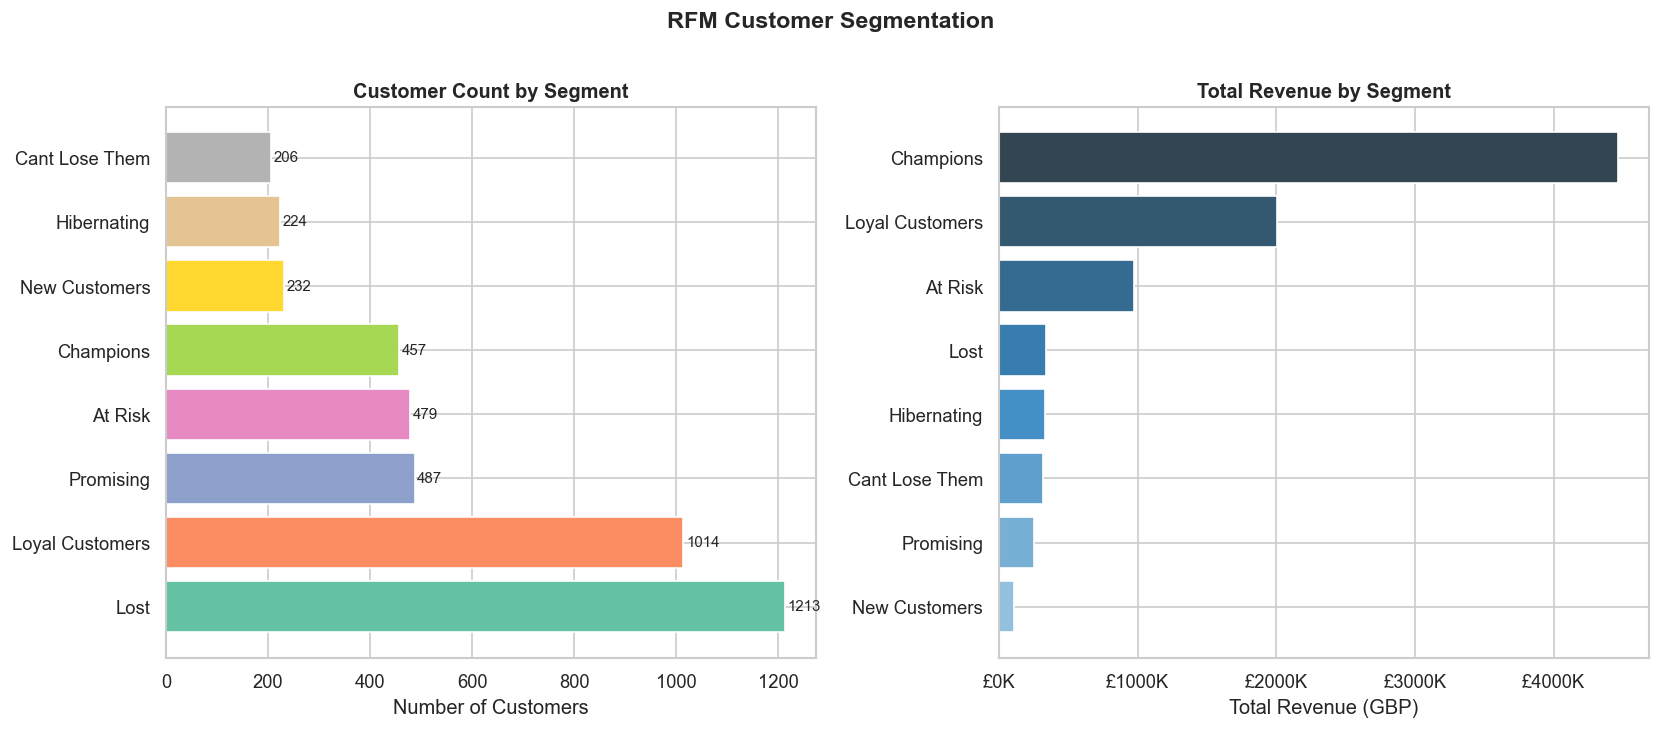

In [35]:
seg_counts = rfm['segment'].value_counts().reset_index()
seg_counts.columns = ['segment', 'count']

palette = sns.color_palette('Set2', len(seg_counts))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: customer count per segment
axes[0].barh(seg_counts['segment'], seg_counts['count'], color=palette)
axes[0].set_title('Customer Count by Segment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Customers')
for i, v in enumerate(seg_counts['count']):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# Right: total revenue per segment
rev_by_seg = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=True).reset_index()
axes[1].barh(rev_by_seg['segment'], rev_by_seg['monetary'],
             color=sns.color_palette('Blues_d', len(rev_by_seg)))
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[1].set_title('Total Revenue by Segment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Revenue (GBP)')

plt.suptitle('RFM Customer Segmentation', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('rfm_segments.png', bbox_inches='tight')
plt.show()

### 5.3 RFM Distribution — Recency, Frequency, Monetary

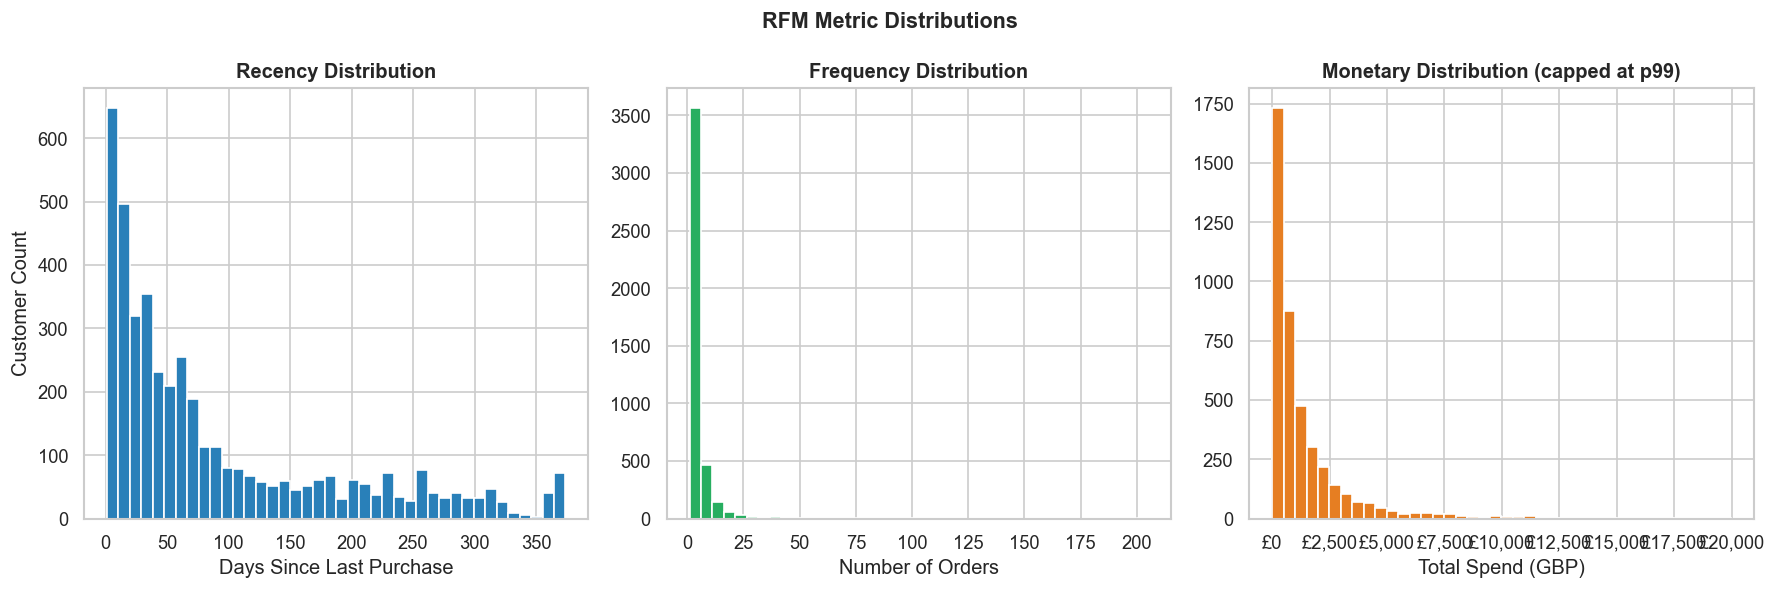

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(rfm['recency'], bins=40, color='#2980B9', edgecolor='white')
axes[0].set_title('Recency Distribution', fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].set_ylabel('Customer Count')

axes[1].hist(rfm['frequency'], bins=40, color='#27AE60', edgecolor='white')
axes[1].set_title('Frequency Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Orders')

# Cap monetary at 99th percentile to remove extreme outliers for viz
m_cap = rfm['monetary'].quantile(0.99)
axes[2].hist(rfm[rfm['monetary'] <= m_cap]['monetary'], bins=40, color='#E67E22', edgecolor='white')
axes[2].set_title('Monetary Distribution (capped at p99)', fontweight='bold')
axes[2].set_xlabel('Total Spend (GBP)')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.suptitle('RFM Metric Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_distributions.png', bbox_inches='tight')
plt.show()

### 5.4 Segment Profile Heatmap

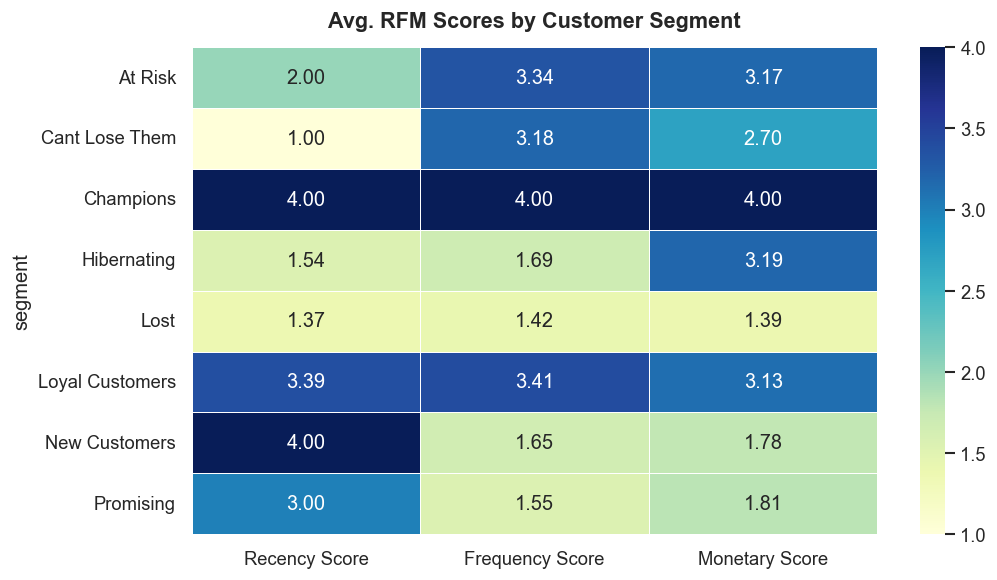

In [37]:
# Average R, F, M scores per segment — normalized for heatmap
heatmap_data = (
    rfm.groupby('segment')[['r_score', 'f_score', 'm_score']]
    .mean()
    .round(2)
    .rename(columns={'r_score': 'Recency Score', 'f_score': 'Frequency Score', 'm_score': 'Monetary Score'})
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5,
    ax=ax,
    vmin=1, vmax=4
)
ax.set_title('Avg. RFM Scores by Customer Segment', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('rfm_heatmap.png', bbox_inches='tight')
plt.show()

## 6. Cohort Retention Analysis

A cohort is a group of customers who made their **first purchase in the same month**.  
We then track what percentage of each cohort came back to buy in subsequent months.  
This tells us directly how well the business retains customers over time.

In [39]:
# Step 1: Find each customer's first purchase month (cohort)
df['order_month'] = df['invoicedate'].dt.to_period('M')

first_purchase = (
    df.groupby('customer_id')['order_month']
    .min()
    .reset_index()
    .rename(columns={'order_month': 'cohort_month'})
)

df = df.merge(first_purchase, on='customer_id', how='left')

# Step 2: Calculate how many months after first purchase each order happened
df['period_number'] = (
    df['order_month'].apply(lambda x: x.ordinal) -
    df['cohort_month'].apply(lambda x: x.ordinal)
)

df.head(3)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,revenue,month,order_month,cohort_month,period_number
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,2009-12,2009-12,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12,2009-12,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12,2009-12,0


In [41]:
# Step 3: Build cohort table — unique customers per cohort per period
cohort_data = (
    df.groupby(['cohort_month', 'period_number'])['customer_id']
    .nunique()
    .reset_index()
)
cohort_data.columns = ['cohort_month', 'period_number', 'n_customers']

# Pivot to matrix form
cohort_pivot = cohort_data.pivot_table(
    index='cohort_month',
    columns='period_number',
    values='n_customers'
)
cohort_pivot.index = cohort_pivot.index.astype(str)
cohort_pivot.columns = [f'Month {c}' if c > 0 else 'Month 0' for c in cohort_pivot.columns]

# Step 4: Convert to retention rate (% of cohort that returned)
cohort_size = cohort_pivot['Month 0']
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

retention.head()

,Month 0,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6,Month 7,Month 8,Month 9,Month 10,Month 11,Month 12
cohort_month,,,,,,,,,,,,,
2009-12,100.0,35.3,33.4,42.5,38.0,35.9,37.7,34.2,33.6,36.2,42.2,49.5,24.8
2010-01,100.0,20.6,31.1,30.5,26.4,30.0,25.8,23.0,27.9,31.9,30.3,9.9,NaN
2010-02,100.0,23.8,22.5,29.1,24.6,20.1,19.3,28.6,25.4,27.5,7.2,NaN,NaN
2010-03,100.0,19.0,23.0,24.2,23.3,20.3,24.6,30.2,27.5,7.9,NaN,NaN,NaN
2010-04,100.0,19.4,19.4,16.3,18.4,22.4,27.6,26.2,6.8,NaN,NaN,NaN,NaN


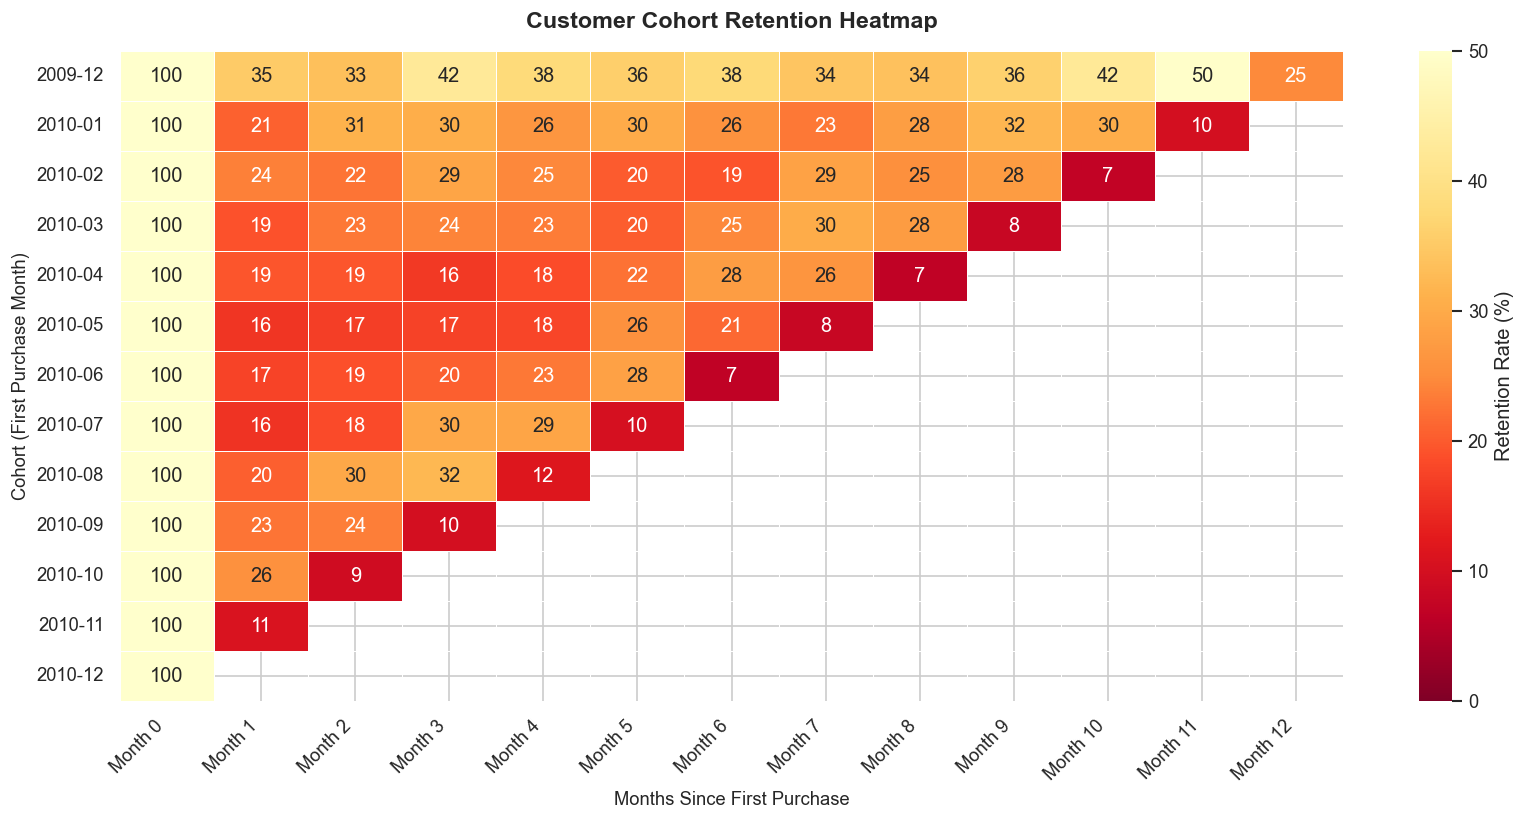

In [42]:
# Step 5: Plot cohort retention heatmap
fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    retention,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd_r',
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    vmin=0, vmax=50,
    cbar_kws={'label': 'Retention Rate (%)'}
)

ax.set_title('Customer Cohort Retention Heatmap', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Cohort (First Purchase Month)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cohort_retention.png', bbox_inches='tight')
plt.show()

### 6.1 Average Retention by Month (across all cohorts)

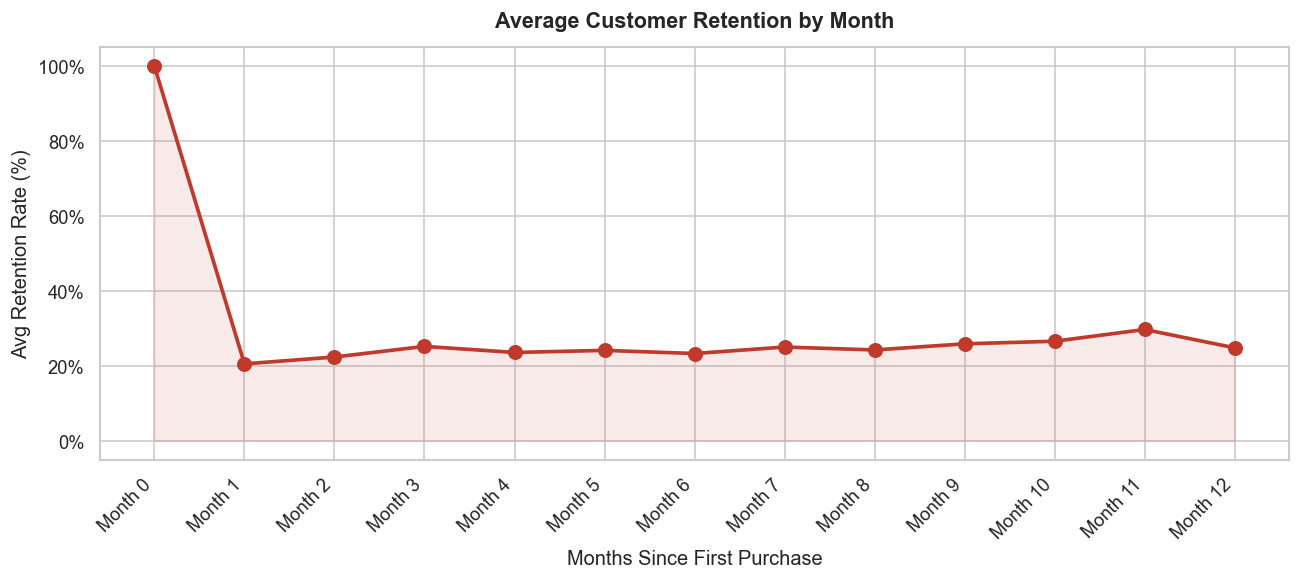

  Period  Avg Retention (%)
 Month 0         100.000000
 Month 1          20.525000
 Month 2          22.354545
 Month 3          25.190000
 Month 4          23.566667
 Month 5          24.125000
 Month 6          23.285714
 Month 7          25.016667
 Month 8          24.240000
 Month 9          25.875000
Month 10          26.566667
Month 11          29.700000
Month 12          24.800000


In [43]:
avg_retention = retention.mean(axis=0).reset_index()
avg_retention.columns = ['Period', 'Avg Retention (%)']

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    avg_retention['Period'],
    avg_retention['Avg Retention (%)'],
    marker='o', linewidth=2.2, color='#C0392B', markersize=8
)
ax.fill_between(
    avg_retention['Period'],
    avg_retention['Avg Retention (%)'],
    alpha=0.1, color='#C0392B'
)
ax.set_title('Average Customer Retention by Month', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Avg Retention Rate (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('avg_retention.png', bbox_inches='tight')
plt.show()

print(avg_retention.to_string(index=False))

## 7. Business Conclusion

This analysis covered ~400K cleaned transactions across ~4,300 unique customers using RFM scoring and cohort retention tracking.

---

**1. Champions and Loyal Customers drive the majority of revenue — but they're a small group.**  
The top two segments (Champions + Loyal) account for a disproportionate share of total revenue relative to customer count. This is a classic 80/20 pattern. The business should prioritize retaining these customers through loyalty programs or early access perks before focusing on acquiring new ones.

**2. A meaningful portion of customers fall in 'At Risk' or 'Hibernating' — they haven't bought in a while but used to.**  
These are reachable with targeted win-back campaigns (discount, personalized email, product recommendation). Letting them lapse entirely is a missed revenue opportunity, since acquiring a new customer costs significantly more than reactivating a dormant one.

**3. Retention drops sharply after the first month — and never fully recovers.**  
The cohort analysis shows that only a fraction of customers who bought in Month 0 come back in Month 1. This points to a weak post-purchase experience. Improving onboarding (follow-up email, cross-sell at delivery) could meaningfully lift Month 1 retention and compound revenue over time.

**4. November–December cohorts retain better — likely seasonal buyers who return for the holidays.**  
This suggests the business has a seasonal loyalty loop worth reinforcing with annual campaigns.

---
*Analysis by: Mohamed Hisham | Dataset: UCI Online Retail via Kaggle | Tools: Python, Pandas, Seaborn, Matplotlib*